# Bank-Marketing

# 1. Importing libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score


# 2. EDA – Exploratory data analysis

## 2.1 Reading the data

In [4]:
data = pd.read_csv(r"Bank-Marketing.txt", sep=';')

In [5]:
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
data.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [8]:
# of records & features
print("# of records : ",data.shape[0])
print("# of features : ", data.shape[1])

# of records :  41188
# of features :  21


`we have 41188 record and 21 feature and we don't have any null values`

## 2.2 data cleaning and analysis

`now lets see if we have any duplicated values and remove them`

In [9]:
data.duplicated().sum() # 12 value
data.drop_duplicates(inplace=True)
data.duplicated().any()

np.False_

`we removed 12 records `

### see if we have balanced data

In [10]:
data['y'].value_counts(normalize=True)

y
no     0.887337
yes    0.112663
Name: proportion, dtype: float64

we clearly see the the data is imbalanced `89% no` and `11% yes`

### Remove and fix Leakage Feature

In [11]:
data = data.drop(columns=['duration'])

- pdays = number of days since client was last contacted in previous campaign
- Value 999 → client was never contacted before.
- Never contacted → pdays = 999
- Contacted before → actual number of days

In [12]:
data['pdays_days'] = data['pdays'].replace(999, 0)

### Encode target values

In [13]:
data['y'] = data['y'].map({'yes':1, 'no':0})

### Check for Correlation

In [14]:
corr = data.corr(numeric_only=True)
corr['y'].sort_values(ascending=False)
abs(corr['y']).sort_values(ascending=False)

y                 1.000000
nr.employed       0.354669
pdays             0.324948
euribor3m         0.307740
emp.var.rate      0.298289
pdays_days        0.267115
previous          0.230202
cons.price.idx    0.136134
campaign          0.066361
cons.conf.idx     0.054802
age               0.030381
Name: y, dtype: float64

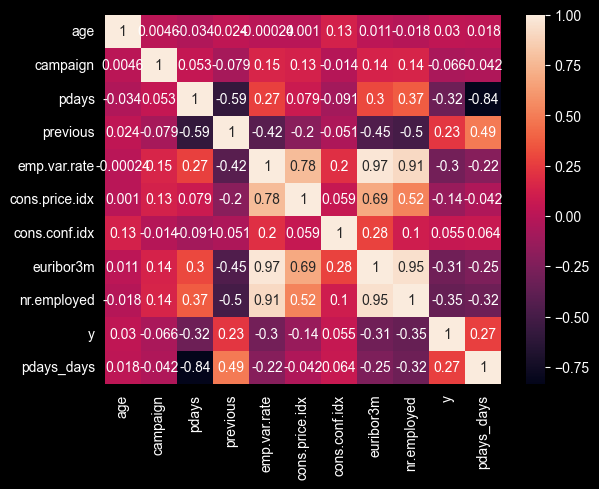

In [15]:
sns.heatmap(corr, annot=True)
plt.show()

 - we clearly see that we **dont** have any strong linear relationship between `y` and other features

### Detect Multicollinearity
- if 2 features have very high corr this mean they almost carry the same information
- Keep only one and drop others

In [16]:
print(corr['emp.var.rate']['euribor3m']) # 0.97
print(corr['euribor3m']["nr.employed"]) # 0.94
print(corr['emp.var.rate']["nr.employed"]) # 0.90

0.972243830979756
0.9451459468620566
0.9069494985179554


In [17]:
data = data.drop(columns=['euribor3m', 'emp.var.rate'])

## Feature Engineering

In [18]:
data['contact_rate'] = data['previous'] / (data['campaign'] + 1)  # +1 to avoid zero division

In [19]:
data['total_contacts'] = data['campaign'] + data['previous']

In [20]:
spring = ['mar', 'apr', 'may']
summer = ['jun', 'jul', 'aug']
autumn = ['sep', 'oct', 'nov']
winter = ['dec', 'jan', 'feb']

def month_to_season(month):
    if month in spring: return 'spring'
    elif month in summer: return 'summer'
    elif month in autumn: return 'autumn'
    else: return 'winter'

data['season'] = data['month'].apply(month_to_season)

### Encode Categorical Features
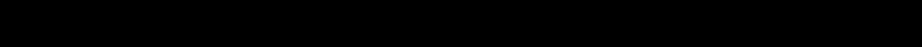
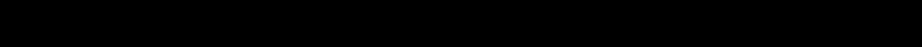

In [21]:
print(data['education'].unique())

['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']


In [22]:
data['education'] = data['education'].map({'unknown':0,'illiterate':1,'basic.4y':2,'basic.6y':3, 'basic.9y':4, 'high.school':5, "university.degree":6,  "professional.course":7})
data["default"] = data["default"].map({'no':0,'yes':1,'unknown':2})
data["housing"] = data["housing"].map({'no':0,'yes':1})
data["loan"] = data["loan"].map({'no':0,'yes':1})

In [23]:
# Label encode nominal columns temporarily
categorical_cols = ['job','marital','education','contact','month','day_of_week','poutcome','season']
for col in categorical_cols:
    data[col] = LabelEncoder().fit_transform(data[col])

In [24]:
data

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,cons.price.idx,cons.conf.idx,nr.employed,y,pdays_days,contact_rate,total_contacts,season
0,56,3,1,2,0,0.0,0.0,1,6,1,...,0,1,93.994,-36.4,5191.0,0,0,0.00,1,1
1,57,7,1,5,2,0.0,0.0,1,6,1,...,0,1,93.994,-36.4,5191.0,0,0,0.00,1,1
2,37,7,1,5,0,1.0,0.0,1,6,1,...,0,1,93.994,-36.4,5191.0,0,0,0.00,1,1
3,40,0,1,3,0,0.0,0.0,1,6,1,...,0,1,93.994,-36.4,5191.0,0,0,0.00,1,1
4,56,7,1,5,0,0.0,1.0,1,6,1,...,0,1,93.994,-36.4,5191.0,0,0,0.00,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,5,1,7,0,1.0,0.0,0,7,0,...,0,1,94.767,-50.8,4963.6,1,0,0.00,1,0
41184,46,1,1,7,0,0.0,0.0,0,7,0,...,0,1,94.767,-50.8,4963.6,0,0,0.00,1,0
41185,56,5,1,6,0,1.0,0.0,0,7,0,...,0,1,94.767,-50.8,4963.6,0,0,0.00,2,0
41186,44,9,1,7,0,0.0,0.0,0,7,0,...,0,1,94.767,-50.8,4963.6,1,0,0.00,1,0


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41176 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  int64  
 2   marital         41176 non-null  int64  
 3   education       41176 non-null  int64  
 4   default         41176 non-null  int64  
 5   housing         40186 non-null  float64
 6   loan            40186 non-null  float64
 7   contact         41176 non-null  int64  
 8   month           41176 non-null  int64  
 9   day_of_week     41176 non-null  int64  
 10  campaign        41176 non-null  int64  
 11  pdays           41176 non-null  int64  
 12  previous        41176 non-null  int64  
 13  poutcome        41176 non-null  int64  
 14  cons.price.idx  41176 non-null  float64
 15  cons.conf.idx   41176 non-null  float64
 16  nr.employed     41176 non-null  float64
 17  y               41176 non-null  int6

### Train Random Forest

In [26]:
# Split features and target
X = data.drop('y', axis=1)
y = data['y']

In [27]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [28]:
importances = rf.feature_importances_
feature_names = X.columns
# Create a sorted pandas Series
feat_importance = pd.Series(importances, index=feature_names).sort_values(ascending=True)

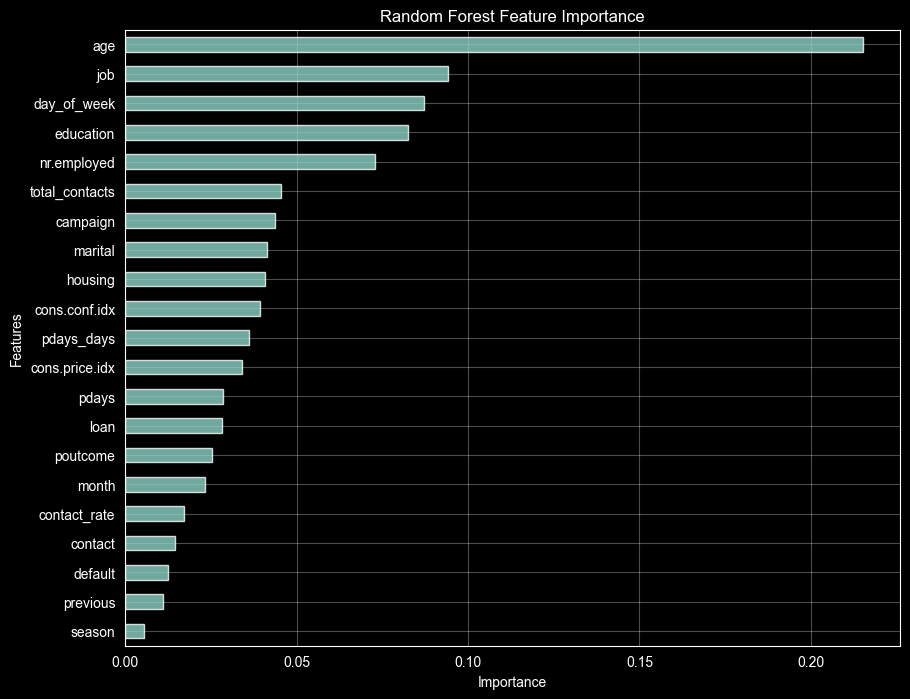

In [29]:
plt.figure(figsize=(10,8))
feat_importance.plot(kind='barh', alpha=0.8, figsize=(10,8))
plt.title("Random Forest Feature Importance")
plt.grid(True, alpha=0.3)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [30]:
data.dropna(inplace=True)

# Training Models
we will choose different models
- logistic regression
- Random Forest
- svm

## Data Splitting

In [31]:
X = data.drop('y', axis=1)
y = data['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [37]:
X_test

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,cons.price.idx,cons.conf.idx,nr.employed,pdays_days,contact_rate,total_contacts,season
37377,21,10,2,5,0,1.0,0.0,1,1,3,...,999,0,1,92.201,-31.4,5076.2,0,0.0,2,2
748,29,0,2,6,0,0.0,0.0,1,6,3,...,999,0,1,93.994,-36.4,5191.0,0,0.0,3,1
37981,41,0,1,6,0,1.0,0.0,0,9,1,...,999,0,1,92.379,-29.8,5017.5,0,0.0,1,0
36674,49,10,1,7,0,0.0,0.0,0,4,0,...,999,0,1,92.963,-40.8,5076.2,0,0.0,1,2
643,54,5,1,5,2,1.0,0.0,1,6,3,...,999,0,1,93.994,-36.4,5191.0,0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28283,39,1,1,4,0,1.0,0.0,0,0,4,...,999,1,0,93.075,-47.1,5099.1,0,0.5,2,1
37595,65,5,1,5,0,0.0,0.0,0,1,1,...,999,1,0,92.201,-31.4,5076.2,0,0.5,2,2
23784,51,1,1,4,2,0.0,0.0,0,1,0,...,999,0,1,93.444,-36.1,5228.1,0,0.0,1,2
24677,33,4,1,6,0,1.0,0.0,0,7,1,...,999,0,1,93.200,-42.0,5195.8,0,0.0,2,0


## Data Sclaing


In [32]:
# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'SVM': SVC(kernel='rbf', C=1, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
}

class_results = {}
for name, clf in models.items():
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    class_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

print("\n=== Classification Model Comparison ===")

print(pd.DataFrame(class_results).T)


=== Classification Model Comparison ===
                     Accuracy  Precision    Recall        F1
Logistic Regression  0.780045   0.294314  0.679162  0.410667
SVM                  0.834287   0.365250  0.635061  0.463768
Random Forest        0.892386   0.544118  0.285557  0.374548
